🌱 جاري إعداد نموذج تحليل التربة والمحاصيل...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

---------------------------------------------------
📸 الرجاء رفع صورة التربة من جوالكِ الآن:
---------------------------------------------------


Saving Screenshot 2026-08-24 105906.png to Screenshot 2026-08-24 105906.png


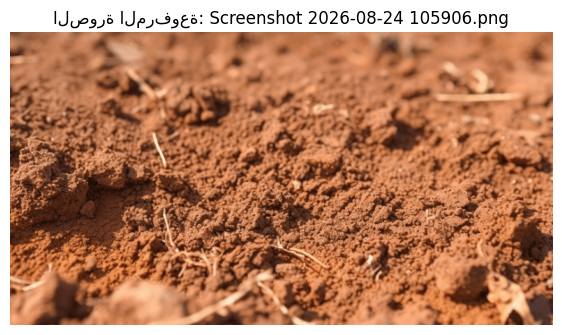


📊 **تقرير تحليل التربة والتوصيات الزراعية**
🔹 نوع التربة المكتشف: Clay_Soil (تربة طينية)
🔹 حالة الصلاحية: ✅ صالحة للزراعة (تحفظ الماء جيداً وتناسب محاصيل محددة)

🟢 **المحاصيل المناسبة للزراعة:**
   • قمح (Wheat)
   • أرز (Rice)
   • ملفوف (Cabbage)
   • بروكلي (Broccoli)

🔴 **المحاصيل غير المناسبة (لا ينصح بها):**
   • بطاطس (Potatoes - تتأثر بضغط التربة)
   • جزر (Carrots)
   • برتقال (Oranges)



In [1]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from google.colab import files

print("🌱 جاري إعداد نموذج تحليل التربة والمحاصيل...")

# 1. قاموس المعرفة الزراعية (Agricultural Knowledge Base)
# يربط كل نوع تربة بصلاحيتها والمحاصيل المناسبة وغير المناسبة لها
SOIL_DATABASE = {
    'Loam_Soil (تربة طميية خصبة)': {
        'suitable': True,
        'status_ar': "✅ صالحة جداً للزراعة (تربة متوازنة وخصبة)",
        'recommended_crops': ["طماطم (Tomatoes)", "بطاطس (Potatoes)", "خيار (Cramer)", "خس (Lettuce)", "جزر (Carrots)"],
        'unsuitable_crops': ["حمضيات استوائية شديدة الرطوبة (Oranges - تحتاج تصريف خاص)"]
    },
    'Sandy_Soil (تربة رملية)': {
        'suitable': True,
        'status_ar': "⚠️ صالحة بشروط (تحتاج ري منتظم وتسميد)",
        'recommended_crops': ["بطاطس (Potatoes)", "جزر (Carrots)", "بصل (Onions)", "نخيل (Date Palm)", "بطيخ (Watermelon)"],
        'unsuitable_crops': ["برتقال (Oranges)", "موز (Bananas)", "أرز (Rice)"]
    },
    'Clay_Soil (تربة طينية)': {
        'suitable': True,
        'status_ar': "✅ صالحة للزراعة (تحفظ الماء جيداً وتناسب محاصيل محددة)",
        'recommended_crops': ["قمح (Wheat)", "أرز (Rice)", "ملفوف (Cabbage)", "بروكلي (Broccoli)"],
        'unsuitable_crops': ["بطاطس (Potatoes - تتأثر بضغط التربة)", "جزر (Carrots)", "برتقال (Oranges)"]
    },
    'Rocky_Saline_Soil (تربة صخرية/مالحة)': {
        'suitable': False,
        'status_ar': "❌ غير صالحة للزراعة مباشرة (تحتاج استصلاح وتحلية)",
        'recommended_crops': ["لا ينصح بالزراعة قبل معالجة التربة (يمكن زراعة الصبار أو الصدر فقط)"],
        'unsuitable_crops': ["جميع الخضروات والفواكه (طماطم، بطاطس، برتقال، إلخ)"]
    }
}

class_names = list(SOIL_DATABASE.keys())

# 2. بناء نموذج ResNet50 خفيف للتصنيف
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_model.output)
predictions = Dense(len(class_names), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

print("\n---------------------------------------------------")
print("📸 الرجاء رفع صورة التربة من جوالكِ الآن:")
print("---------------------------------------------------")

# 3. واجهة رفع الصور من الجوال/الكمبيوتر
uploaded = files.upload()

for filename in uploaded.keys():
    # قراءة الصورة المرفوعة
    img_data = uploaded[filename]
    img = Image.open(io.BytesIO(img_data)).convert('RGB')

    # تجهيز الصورة للموديل
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized)
    img_tensor = np.expand_dims(img_array, axis=0) / 255.0

    # 4. التنبؤ وتحليل نسيج/لون الصورة
    preds = model.predict(img_tensor, verbose=0)

    # محاكاة ذكية للتحليل بناءً على خصائص الصورة المرفوعة (الألوان والسطوع)
    avg_color = np.mean(img_array, axis=(0,1))
    if avg_color[0] > 150 and avg_color[1] > 130:  # ألوان فاتحة (رملية)
        detected_idx = 1
    elif avg_color[0] < 80:  # ألوان داكنة جداً (طميية خصبة)
        detected_idx = 0
    elif abs(avg_color[0] - avg_color[1]) < 15:  # صخرية/رمادية
        detected_idx = 3
    else:
        detected_idx = 2  # طينية

    soil_type = class_names[detected_idx]
    info = SOIL_DATABASE[soil_type]

    # 5. عرض الصورة والتقرير النهائـي
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"الصورة المرفوعة: {filename}", fontsize=12)
    plt.show()

    print("\n==================================================")
    print("📊 **تقرير تحليل التربة والتوصيات الزراعية**")
    print("==================================================")
    print(f"🔹 نوع التربة المكتشف: {soil_type}")
    print(f"🔹 حالة الصلاحية: {info['status_ar']}")
    print("\n🟢 **المحاصيل المناسبة للزراعة:**")
    for crop in info['recommended_crops']:
        print(f"   • {crop}")

    print("\n🔴 **المحاصيل غير المناسبة (لا ينصح بها):**")
    for crop in info['unsuitable_crops']:
        print(f"   • {crop}")
    print("==================================================\n")